In [5]:
from pathlib import Path
import pandas as pd

path = Path("software_daq") /"export" / "export_matrix_scan_251113_165652_cap50.tsv"

if not path.exists():
    raise FileNotFoundError(f"File non trovato: {path.resolve()}")

df = pd.read_csv(path, sep="\t", encoding="utf-8", engine="python")
df.head()

,row,col,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa
0,0,0,65,3.00,0.000,15.7,0.823,1.0,1.0
1,0,0,61,3.00,0.000,16.7,0.675,1.0,1.0
2,0,0,57,2.40,0.516,19.2,1.549,1.0,1.0
3,0,0,53,1.90,0.316,22.1,1.912,1.0,1.0
4,0,0,49,1.25,0.463,29.7,5.143,0.8,1.0


In [6]:
import numpy as np
from scipy.special import erf
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt

# erf S-curve model
def myERF(x, mu, sigma):
    x = np.asarray(x)
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2.0))))

#cols = ["efficiency_tot", "efficiency_toa"]
cols = ["efficiency_toa"]
results = []

# group by pixel (row, col)
for (r, c), group in df.groupby(["row", "col"]):
    x_min, x_max = group["voltage"].min(), group["voltage"].max()
    for col in cols:
        if col not in group.columns:
            continue
        valid = group[["voltage", col]].dropna()
        npts = len(valid)
        if npts < 4:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": np.nan, "dispersion": np.nan, "success": False}
            )
            continue

        xdata = valid["voltage"].values
        ydata = valid[col].values

        guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
        try:
            popt, pcov = curve_fit(
                myERF,
                xdata,
                ydata,
                p0=guess,
                bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                maxfev=5000,
            )
            fit_mu, fit_sigma = float(popt[0]), float(popt[1])
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
            )
        except Exception:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": np.nan, "dispersion": np.nan, "success": False}
            )

# results dataframe
fit_df = pd.DataFrame(results)
fit_out_path = path.parent / "fit_results_per_pixel.csv"
fit_df.to_csv(fit_out_path, index=False)
print(f"Saved {len(fit_df)} fit records to: {fit_out_path}")



Saved 256 fit records to: software_daq\export\fit_results_per_pixel.csv


Soglia media: 58.86 ± 25.24


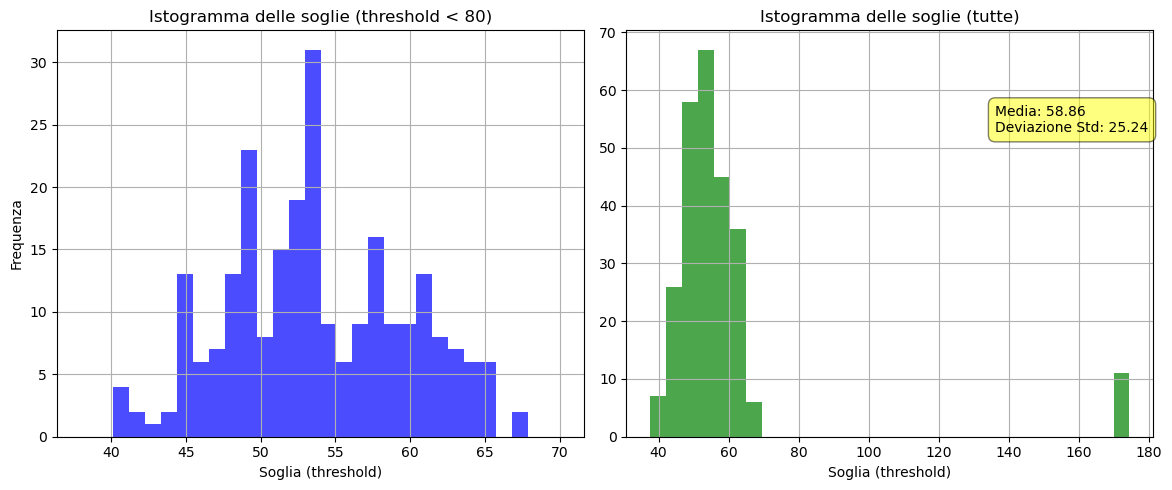

In [11]:
# Visualizza gli elementi della colonna 'threshold' del dataframe fit_df

thr_lt350 = fit_df.loc[fit_df["threshold"] < 200, "threshold"]
#soglie minori di 200 e maggiori di 50

#thr_lt350 = fit_df.loc[(fit_df["threshold"] < 200) & (fit_df["threshold"] > 52), "threshold"] 

# calcola media e deviazione standard delle soglie
mean_threshold = thr_lt350.mean()
std_threshold = thr_lt350.std()
print(f"Soglia media: {mean_threshold:.2f} ± {std_threshold:.2f}")


# affianca i due istogrammi (side-by-side)
fig_hist, axs_hist = plt.subplots(1, 2, figsize=(12, 5))

axs_hist[0].hist(thr_lt350.dropna(), bins=30, color='blue', alpha=0.7, range=(38, 70))
axs_hist[0].set_title("Istogramma delle soglie (threshold < 80)")
axs_hist[0].set_xlabel("Soglia (threshold)")
axs_hist[0].set_ylabel("Frequenza")
axs_hist[0].grid(True)

axs_hist[1].hist(fit_df["threshold"].dropna(), bins=30, color='green', alpha=0.7)
axs_hist[1].set_title("Istogramma delle soglie (tutte)")
axs_hist[1].set_xlabel("Soglia (threshold)")
axs_hist[1].grid(True)

# annotazione con media e deviazione standard
axs_hist[1].annotate(f"Media: {mean_threshold:.2f}\nDeviazione Std: {std_threshold:.2f}",
                     xy=(0.70, 0.75), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5))

plt.tight_layout()
plt.show()




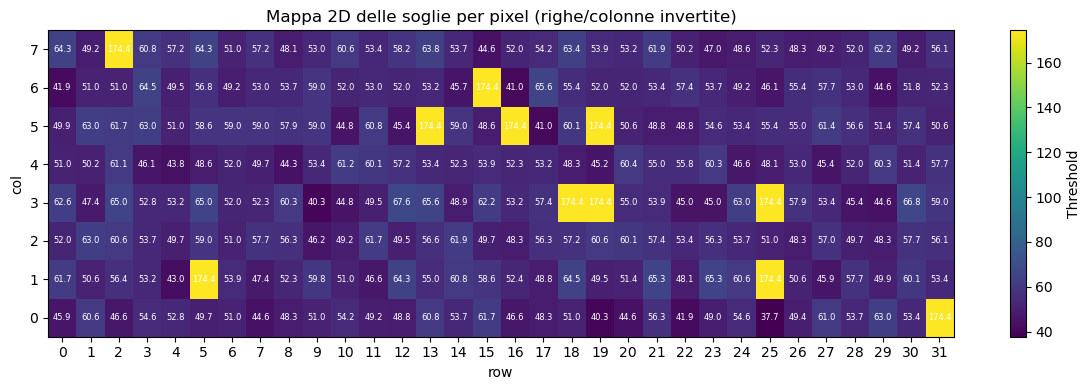

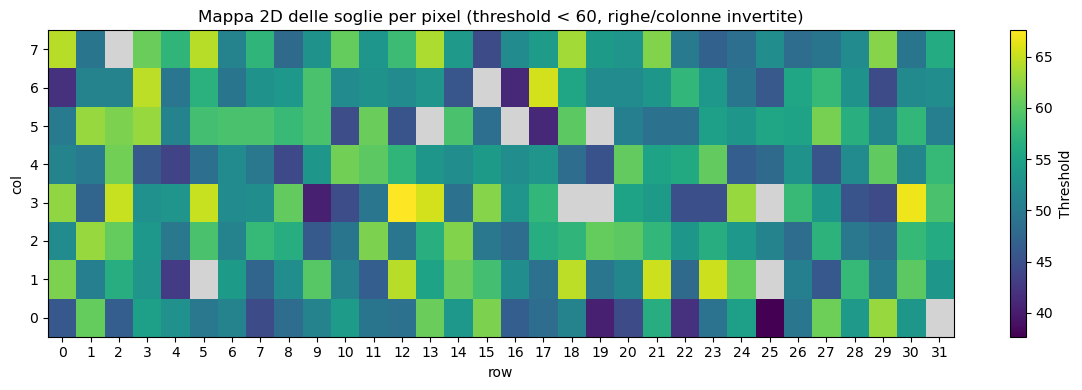

In [12]:
# righe e colonne scambiate: costruisco la mappa con shape (n_col, n_row)


n_row = int(fit_df["row"].max()) + 1
n_col = int(fit_df["col"].max()) + 1
thr_map = np.full((n_col, n_row), np.nan)  # note: rows=col, cols=row

for _, r in fit_df.iterrows():
    # pos: (original col, original row)
    thr_map[int(r["col"]), int(r["row"])] = r["threshold"] if r.get("success", True) else np.nan

masked = np.ma.masked_invalid(thr_map)
cmap = cmap if 'cmap' in globals() else plt.cm.viridis.copy()
try:
    cmap = cmap.copy()
    cmap.set_bad(color="lightgray")
except Exception:
    pass

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(masked, origin="lower", cmap=cmap, interpolation="nearest", aspect="auto")

# ora asse X = row (original), asse Y = col (original)
ax.set_xlabel("row")
ax.set_ylabel("col")
ax.set_xticks(np.arange(n_row))
ax.set_yticks(np.arange(n_col))

# etichette più sparse se troppe
if n_row > 32:
    ax.set_xticks(np.arange(0, n_row, max(1, n_row // 16)))
if n_col > 16:
    ax.set_yticks(np.arange(0, n_col, max(1, n_col // 8)))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Threshold")

# annota valori (attento: molti pixel -> disabilitare)
for i in range(n_col):       # i corrisponde all'originale col
    for j in range(n_row):   # j corrisponde all'originale row
        v = thr_map[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6, color="white")

ax.set_title("Mappa 2D delle soglie per pixel (righe/colonne invertite)")
plt.tight_layout()
plt.show()

# versione filtrata (threshold < 60)
masked_filtered = np.ma.masked_invalid(np.where(thr_map < 70, thr_map, np.nan))
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(masked_filtered, origin="lower", cmap=cmap, interpolation="nearest", aspect="auto")

ax.set_xlabel("row")
ax.set_ylabel("col")
ax.set_xticks(np.arange(n_row))
ax.set_yticks(np.arange(n_col))
if n_row > 32:
    ax.set_xticks(np.arange(0, n_row, max(1, n_row // 16)))
if n_col > 16:
    ax.set_yticks(np.arange(0, n_col, max(1, n_col // 8)))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Threshold")
ax.set_title("Mappa 2D delle soglie per pixel (threshold < 60, righe/colonne invertite)")
plt.tight_layout()
plt.show()


Dispersion < 14: mean = 1.19, std = 0.61


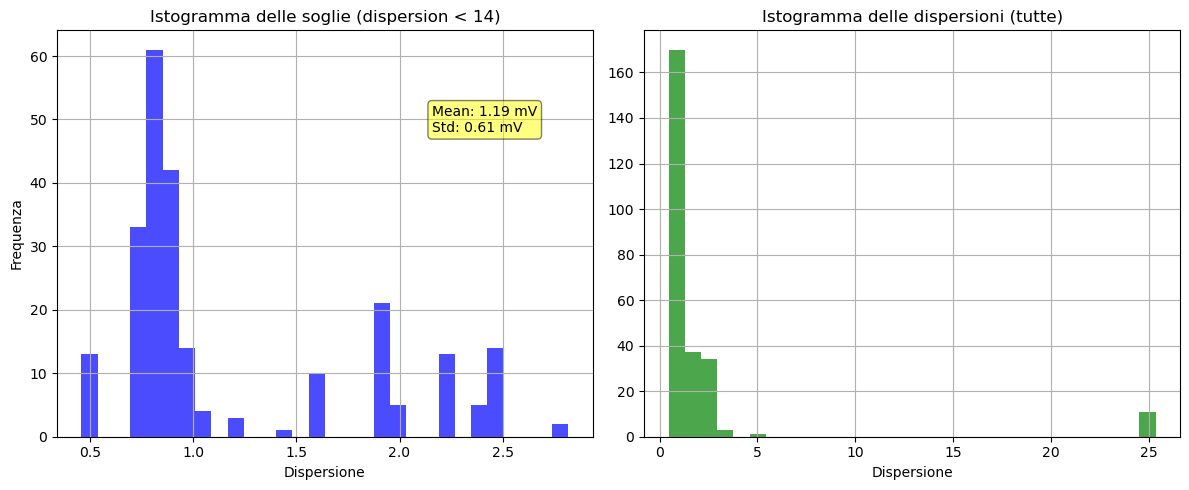

In [13]:
# Visualizza gli elementi della colonna 'threshold' del dataframe fit_df

#for v in fit_df["dispersion"]:
#    print(v)
thr_lt14 = fit_df.loc[fit_df["dispersion"] < 3, "dispersion"]





# calcola media e deviazione standard della distribuzione di thr_lt14 se fit gaussiana
mean_dispersion = thr_lt14.mean()
std_dispersion = thr_lt14.std()

print(f"Dispersion < 14: mean = {mean_dispersion:.2f}, std = {std_dispersion:.2f}")


# affianca i due istogrammi (side-by-side)
fig_hist, axs_hist = plt.subplots(1, 2, figsize=(12, 5))

axs_hist[0].hist(thr_lt14.dropna(), bins=30, color='blue', alpha=0.7)
    
axs_hist[0].set_title("Istogramma delle soglie (dispersion < 14)")
axs_hist[0].set_xlabel("Dispersione")
axs_hist[0].set_ylabel("Frequenza")
axs_hist[0].grid(True)



axs_hist[1].hist(fit_df["dispersion"].dropna(), bins=30, color='green', alpha=0.7)
axs_hist[1].set_title("Istogramma delle dispersioni (tutte)")
axs_hist[1].set_xlabel("Dispersione")
axs_hist[1].grid(True)

# annotazione con media e deviazione standard
axs_hist[0].annotate(f"Mean: {mean_dispersion:.2f} mV\nStd: {std_dispersion:.2f} mV",
                     xy=(0.70, 0.75), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.tight_layout()
plt.show()


In [16]:

# 1. Funzione ERF (S-Curve)
# Assumiamo che myERF sia definita in questo modo per l'S-curve (integral della Gaussiana)
def myERF(x, mu, sigma):
    """Funzione di errore (ERF) per il fit dell'S-curve."""
    # Modello tipico: 0.5 * (1 + erf((x - mu) / (sigma * sqrt(2))))
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2))))

# 2. Nuova funzione per plottare una singola curva fittata su un oggetto Axes
def plot_single_fit_on_ax(ax, popt, r, c, col):
    """
    Disegna la curva ERF fittata sull'oggetto Axes fornito.
    """
    fit_mu, fit_sigma = popt[0], popt[1]
    
    # Crea 100 punti per un tracciato liscio della curva
    # Utilizza un range arbitrario o basato sui dati se noto
    x_fit = np.linspace(40, 60, 100)  # Modifica questo range se necessario
    y_fit = myERF(x_fit, fit_mu, fit_sigma)
    
    label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"
    
    # Aggiungi il plot all'Axes
    ax.plot(x_fit, y_fit, alpha=0.5, label=label)
# 3. Funzione principale per l'elaborazione del DataFrame
def fit_erf_to_scurves(df, cols=["efficiency_toa"], plot_title="Sovrapposizione S-Curves Fittate"):
    """
    Esegue il fit della S-curve ERF sui dati raggruppati per pixel e crea un plot sovrapposto.

    Args:
        df (pd.DataFrame): DataFrame contenente i dati.
        cols (list): Lista delle colonne metriche su cui eseguire il fit.
        plot_title (str): Titolo per il plot di sovrapposizione.

    Returns:
        pd.DataFrame: DataFrame con i risultati del fit (threshold, dispersion, successo).
    """
    results = []
    
    # 3.1. Inizializzazione del plot per la sovrapposizione
    #fig, ax = plt.subplots(figsize=(10, 7))
    #ax.set_title(plot_title)
    #ax.set_xlabel("Voltage (Tensione)")
    #ax.set_ylabel(f"Fit S-Curve ({', '.join(cols)})")
    
    # 3.2. Raggruppa i dati per pixel (row, col)
    for (r, c), group in df.groupby(["row", "col"]):
        
        # Itera su tutte le colonne metriche specificate
        for col in cols:
            if col not in group.columns:
                continue

            # Prepara i dati
            valid = group[["voltage", col]].dropna()
            npts = len(valid)

            # Controllo minimo punti per il fit
            if npts < 4:
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )
                continue

            xdata = valid["voltage"].values
            ydata = valid[col].values

            # Stima iniziale dei parametri (guess)
            guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
            
            # 3.3. Esegue il fit
            try:
                popt, pcov = curve_fit(
                    myERF,
                    xdata,
                    ydata,
                    p0=guess,
                    bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                    maxfev=5000,
                )
                fit_mu, fit_sigma = float(popt[0]), float(popt[1])
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
                )

                # 3.4. Aggiunge il fit al plot di sovrapposizione
                plot_single_fit_on_ax(ax, popt, r, c, col)
                
            except Exception as e:
                # Gestione dell'errore nel fit
                print(f"Fit fallito per pixel ({r}, {c}), metrica {col}: {e}")
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )

    # 3.5. Finalizzazione del plot (dopo il ciclo)
    # Rimuovi il codice per la legenda se il numero di curve è elevato, 
    # altrimenti potrebbe rendere il plot illeggibile.
    # Se vuoi solo un'idea della distribuzione, non mettere la legenda.
    
    # ax.legend(loc='best', fontsize='small') # Abilita se hai pochi pixel
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Salva il plot in un file (opzionale)
    #plt.savefig(f"{'_'.join(cols)}_overlapped_fits.png")
    
    # Mostra il plot (opzionale)
    plt.show() 
    
    plt.close(fig) # Chiudi la figura per liberare memoria

    # 3.6. Ritorna il DataFrame dei risultati
    return pd.DataFrame(results)

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\andre\AppData\Local\Temp\ipykernel_19524\764190429.py:20: SyntaxWarning: invalid escape sequence '\m'
  label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"
C:\Users\andre\AppData\Local\Temp\ipykernel_19524\764190429.py:20: SyntaxWarning: invalid escape sequence '\s'
  label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"


In [17]:
fit_results_df = fit_erf_to_scurves(fit_df, cols=["efficiency_toa"])
